# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

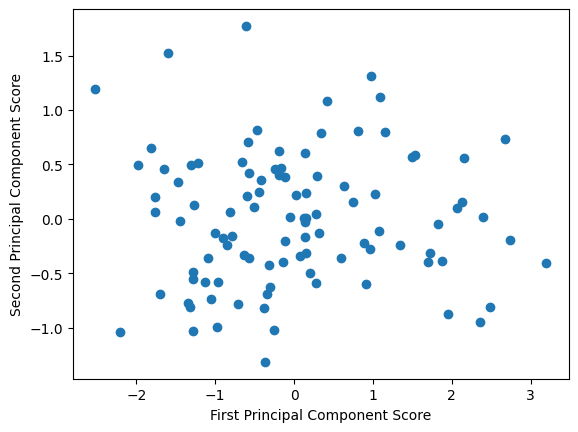

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

What can be said about the three outliers in the upper left corner of the graph? 
  - The three outliers have a low PC1 and a high PC2 score, meaning the data is far below the direction of the firs eigenvector and significantly higher from the second eignenvector. This translates to the data being outside (lower) than the general spread of the data and outside (higher) than the orthogonal (perpendicular) spread of the data.
 
Is their first principal component score high or low?
  - Their first principal component is low.  
 
What about their second principal component score?  
  - Their second principal component is high.
 
What does that mean about their values in series_1, series_2, and series_3?  
  - series_1: outliers are likely above the mean because they have a high PC2 score.
  - series_2: outliers are likely above the mean because because they have a high PC2 score.
  - series_3: outliers are likely significantly below the mean because they have a low PC1 score.
 
It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  
  - This is because series_3 has a higher scale than the others while series_1 and series_2 are highly correlated.
 
How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.
  - They are related because series_2 is a direct function of series_1 with a more similar scale (0.1) compared to series_3 which has a larger scale (0.5).
  
Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?
  - Compared to PCA, this graph shows the actual data rather than the "summary" of how the majority of the data lies. You can see the individual feature relationships and distributions. One major disadvantage for pairplots are if there are a lot of features because it creates an n x n grid. Interestingly, series_1 and series_2 are highly correlated while the other feature relationships are more scattered and less defined linearly.

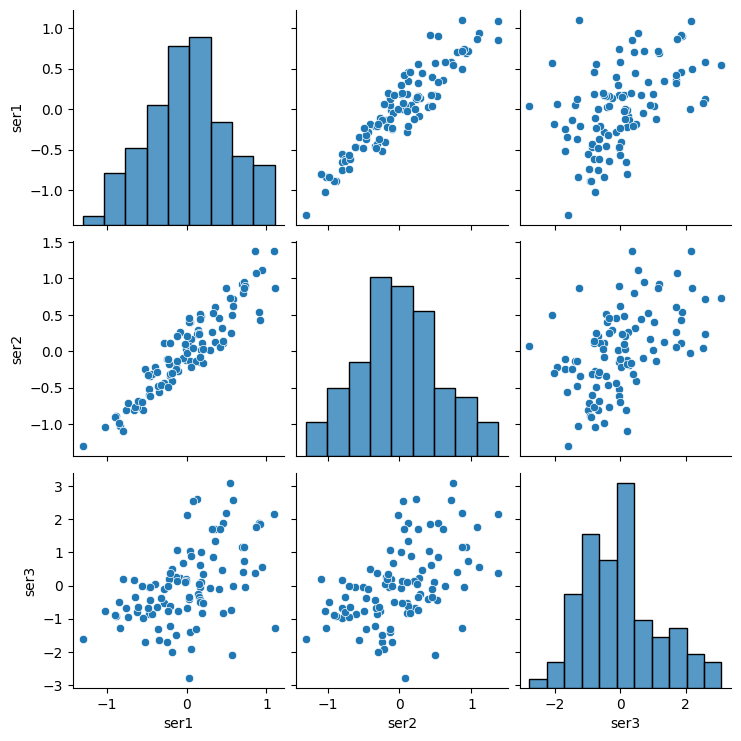

In [2]:
sns.pairplot(df)

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
cancer_rates = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(COMBINED) Cancer Rates.csv")
cancer_deaths = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(COMBINED) cancer_deaths.csv")
census_pop = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(IMPUTED) census_pop_county.csv")
house_income = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(IMPUTED) RESHAPED Unemployment and median household income.csv")
life_expect_kff = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\KFF - life expectancy at birth by race.csv")
life_expect_nchs = pd.read_csv(r"..\Projects\Health Disparities Analytics\Processed Data\NCHS_-_Death_rates_and_life_expectancy_at_birth.csv")

In [4]:
pd.set_option('display.max_columns', None)

##### Heatmaps

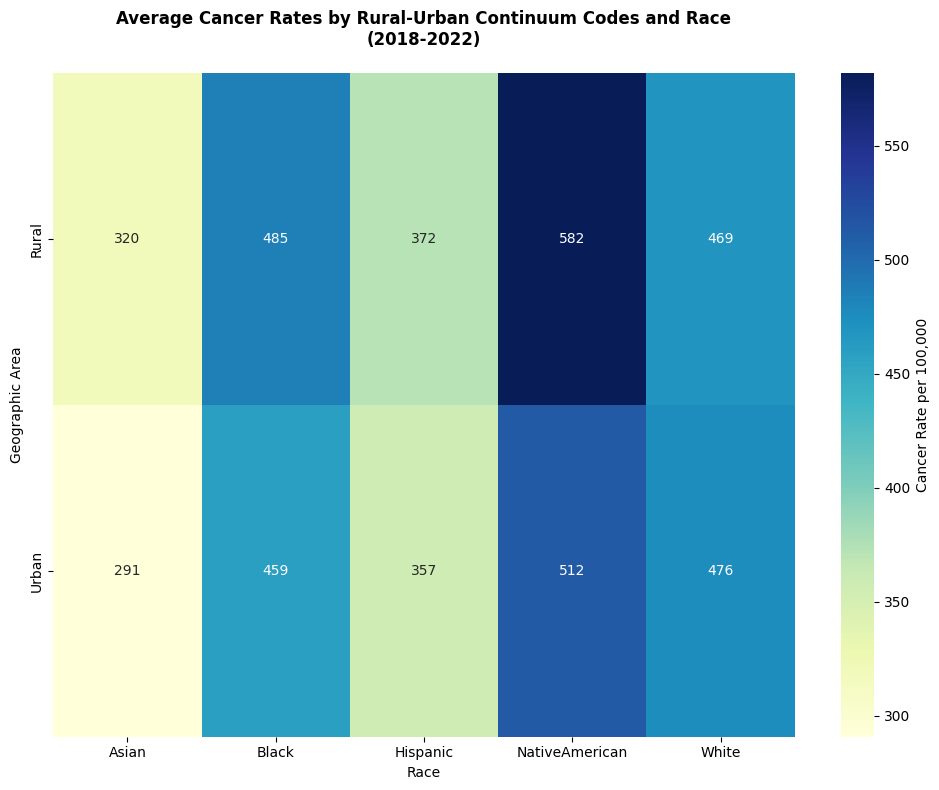

In [5]:
# cancer_rates.info()

# Need to remove data for flagged values so the data isn't skewed on the visuals

flag_map = {
    '*': -9999,
    '[P1 note]': -9998,
    '[P3 note]': -9997,
    '[S3 note]': -9996,
    '&para': -9995,

    'rising': -8888,
    'falling': -8887,
    'stable': -8886
}

flag_values = list(flag_map.values())

cancer_rates_filtered = cancer_rates.copy()
cancer_rates_filtered['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'] = cancer_rates_filtered['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'].replace(flag_values, np.nan)

cancer_rates_pivot = cancer_rates_filtered.pivot_table(
    index="2023 Rural-Urban Continuum Codes([rural urban note])", 
    columns="Race", 
    values="Age-Adjusted Incidence Rate([rate note]) - cases per 100,000", 
    aggfunc='median'  
)

plt.figure(figsize=(10, 8))

sns.heatmap(cancer_rates_pivot, 
            annot=True, 
            cmap="YlGnBu", 
            fmt='.0f',
            cbar_kws={'label': 'Cancer Rate per 100,000'})

plt.title("Average Cancer Rates by Rural-Urban Continuum Codes and Race\n(2018-2022)", pad=20, fontweight='bold')
plt.ylabel("Geographic Area")
plt.tight_layout()
plt.show()

Geographic Areas:
  - Rural: All racial groups have higher cancer rates compared to Urban areas

Race:
  - Native Americans have the highest cancer rates compared to all other racial group
  - White people have the second highest cancer rates
  - Black people have the third highest cancer rates

Note:
  - The data is still skewed because there are significantly more data for White people compared to all other racial groups. 

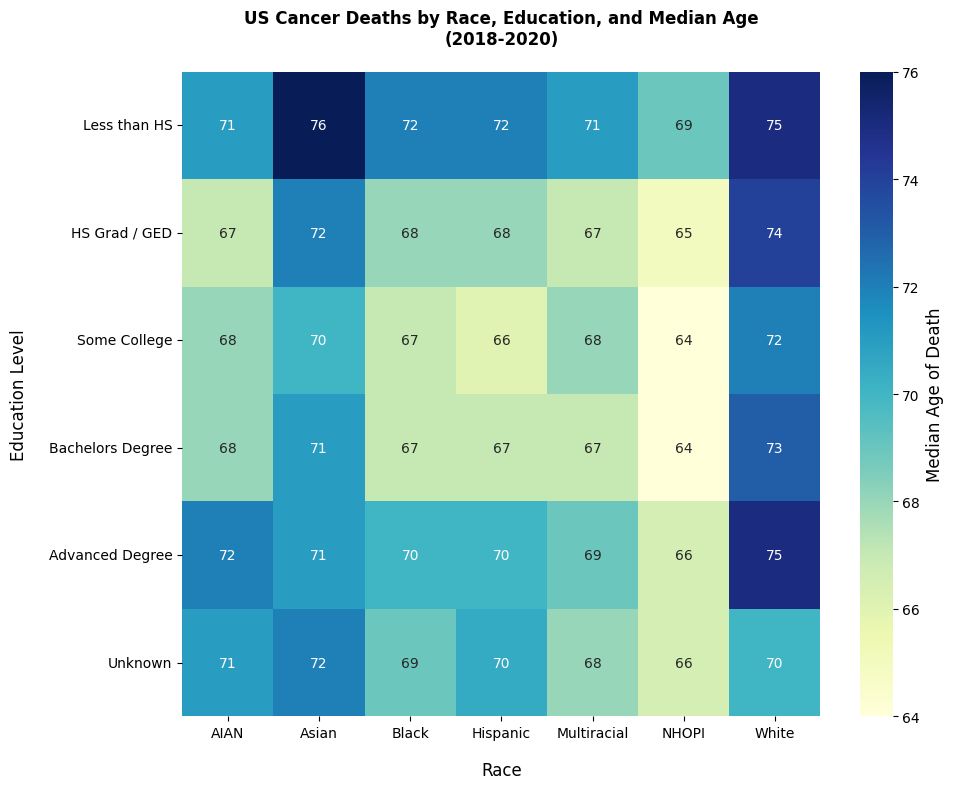

In [6]:
# cancer_deaths.info()

edu_order = [
    "Less than HS",
    "HS Grad / GED",
    "Some College",
    "Bachelors Degree",
    "Advanced Degree",
    "Unknown"
]

cancer_death_pivot = cancer_deaths.pivot_table(
    index="EDUCATION", 
    columns="RACE", 
    values="AGE", 
    aggfunc='median'  
)

# Order the data by the EDUCATION order I set above
cancer_death_pivot = cancer_death_pivot.reindex(edu_order)

plt.figure(figsize=(10, 8))

ax = sns.heatmap(cancer_death_pivot, 
            annot=True, 
            cmap="YlGnBu", 
            cbar_kws={'label': 'Median Age of Death'})

# Access the colorbar to adjust the label size
ax.figure.axes[-1].yaxis.label.set_size(12)

plt.title("US Cancer Deaths by Race, Education, and Median Age\n(2018-2020)", pad=20, fontweight='bold')

plt.xlabel("Race", labelpad=15, fontsize=12)
plt.ylabel("Education Level", labelpad=15, fontsize=12)
plt.tight_layout()
plt.show()

Education:
  - Less than HS and Advanced Degree seem to have the highest cancer deaths compared to other educational attainment categories
  - HS Grad / GED, Some College, and Bachelors Degree tend to have the lowest median age of death from cancer

Races:
  - White people have the oldest median age of death from cancer compared to all other races
  - Native Hawaiian and Other Pacific Islander people (NHOPI) have the lowest median age of death from cancer

##### Bubble Plots

In [7]:
census_pop.describe()

,STATEFP,STATENH,COUNTYFP,COUNTYNH,total_pop_1970,total_pop_1980,total_pop_1990,total_pop_2000,total_pop_2010,total_pop_2020,male_pop_1970,male_pop_1980,male_pop_1990,male_pop_2000,male_pop_2010,male_pop_2020,female_pop_1970,female_pop_1980,female_pop_1990,female_pop_2000,female_pop_2010,female_pop_2020,pop_under_5_years_1970,pop_under_5_years_1980,pop_under_5_years_1990,pop_under_5_years_2000,pop_under_5_years_2010,pop_under_5_years_2020,pop_5_9_years_1970,pop_5_9_years_1980,pop_5_9_years_1990,pop_5_9_years_2000,pop_5_9_years_2010,pop_5_9_years_2020,pop_10_14_years_1970,pop_10_14_years_1980,pop_10_14_years_1990,pop_10_14_years_2000,pop_10_14_years_2010,pop_10_14_years_2020,pop_15_17_years_1970,pop_15_17_years_1980,pop_15_17_years_1990,pop_15_17_years_2000,pop_15_17_years_2010,pop_15_17_years_2020,pop_18_19_years_1970,pop_18_19_years_1980,pop_18_19_years_1990,pop_18_19_years_2000,pop_18_19_years_2010,pop_18_19_years_2020,pop_20_years_1970,pop_20_years_1980,pop_20_years_1990,pop_20_years_2000,pop_20_years_2010,pop_20_years_2020,pop_21_years_1970,pop_21_years_1980,pop_21_years_1990,pop_21_years_2000,pop_21_years_2010,pop_21_years_2020,pop_22_24_years_1970,pop_22_24_years_1980,pop_22_24_years_1990,pop_22_24_years_2000,pop_22_24_years_2010,pop_22_24_years_2020,pop_25_29_years_1970,pop_25_29_years_1980,pop_25_29_years_1990,pop_25_29_years_2000,pop_25_29_years_2010,pop_25_29_years_2020,pop_30_34_years_1970,pop_30_34_years_1980,pop_30_34_years_1990,pop_30_34_years_2000,pop_30_34_years_2010,pop_30_34_years_2020,pop_35_44_years_1970,pop_35_44_years_1980,pop_35_44_years_1990,pop_35_44_years_2000,pop_35_44_years_2010,pop_35_44_years_2020,pop_45_54_years_1970,pop_45_54_years_1980,pop_45_54_years_1990,pop_45_54_years_2000,pop_45_54_years_2010,pop_45_54_years_2020,pop_55_59_years_1970,pop_55_59_years_1980,pop_55_59_years_1990,pop_55_59_years_2000,pop_55_59_years_2010,pop_55_59_years_2020,pop_60_61_years_1970,pop_60_61_years_1980,pop_60_61_years_1990,pop_60_61_years_2000,pop_60_61_years_2010,pop_60_61_years_2020,pop_62_64_years_1970,pop_62_64_years_1980,pop_62_64_years_1990,pop_62_64_years_2000,pop_62_64_years_2010,pop_62_64_years_2020,pop_65_74_years_1970,pop_65_74_years_1980,pop_65_74_years_1990,pop_65_74_years_2000,pop_65_74_years_2010,pop_65_74_years_2020,pop_75_84_years_1970,pop_75_84_years_1980,pop_75_84_years_1990,pop_75_84_years_2000,pop_75_84_years_2010,pop_75_84_years_2020,pop_85_years_and_older_1970,pop_85_years_and_older_1980,pop_85_years_and_older_1990,pop_85_years_and_older_2000,pop_85_years_and_older_2010,pop_85_years_and_older_2020
count,3248.000000,3248.000000,3248.000000,3248.000000,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3.248000e+03,3.248000e+03,3.248000e+03,3.248000e+03,3248.000000,3248.000000,3248.000000,3.248000e+03,3.248000e+03,3.248000e+03,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.00000

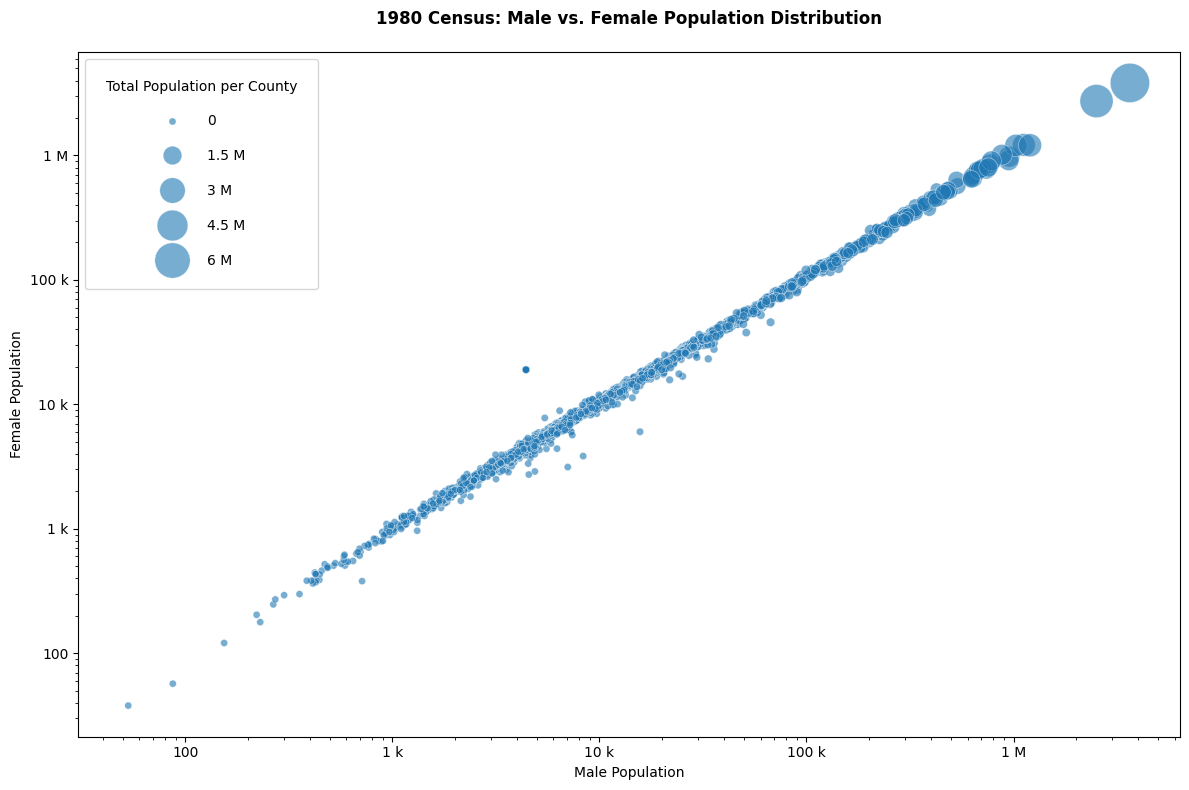

In [14]:
min_pop = census_pop['total_pop_1980'].min()
max_pop = census_pop['total_pop_1980'].max()

max_bubble_size = 500

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    x=census_pop['male_pop_1980'],
    y=census_pop['female_pop_1980'],
    size=census_pop['total_pop_1980'],
    sizes=(20, 800),
    alpha=0.6,
    legend="brief"
)

# Improve view since outlier counties make most of the data difficult to read
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# Create the formatter instance for legend
formatter = ticker.EngFormatter()

# Force the legend to update and grab the handles/labels
handles, labels = ax.get_legend_handles_labels()

# Format the labels using EngFormatter
eng_fmt = ticker.EngFormatter()
new_labels = []

for label in labels:
    try:
        # Remove any existing commas or spaces, then convert to float
        clean_label = label.replace(',', '').strip()
        formatted_label = eng_fmt.format_data(float(clean_label))
        new_labels.append(formatted_label)
    except ValueError:
        # If it's the title (e.g., "total_pop_1980"), keep it as is
        new_labels.append(label)

# 4. Re-apply the legend with the new labels
ax.legend(handles=handles, labels=new_labels, title="Total Population per County", 
          labelspacing=1.5, 
          borderpad=1.5,
          handletextpad=1.5)

ax.set_title("1980 Census: Male vs. Female Population Distribution", pad=20, fontweight='bold')
ax.set_xlabel("Male Population")
ax.set_ylabel("Female Population")


plt.tight_layout()
plt.show()

AI Acknowledgment: [Used Gemini to fix the formatting of the legend to match the x and y formatting](https://gemini.google.com/share/4063c9315dbc)

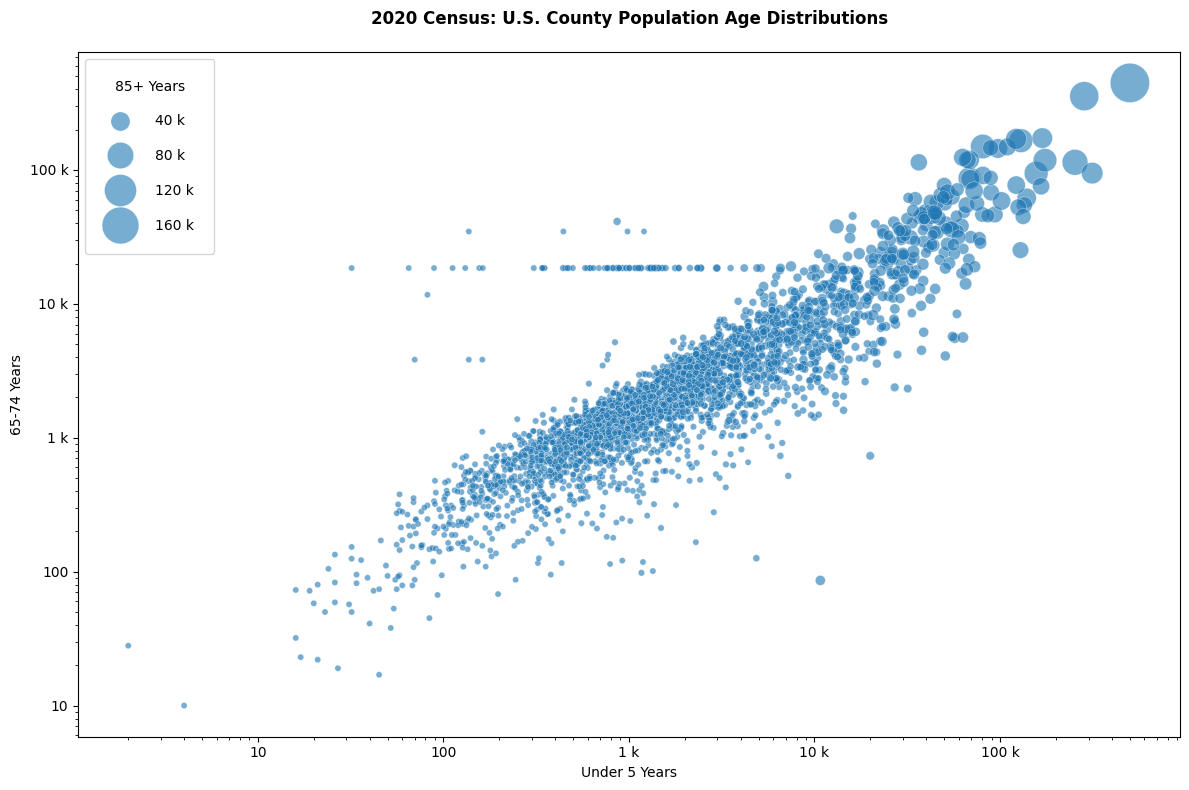

In [13]:
min_pop = census_pop['pop_85_years_and_older_2020'].min()
max_pop = census_pop['pop_85_years_and_older_2020'].max()

max_bubble_size = 500

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    x=census_pop['pop_under_5_years_2020'],
    y=census_pop['pop_65_74_years_1980'],
    size=census_pop['pop_85_years_and_older_2020'],
    sizes=(20, 800),
    alpha=0.6,
    legend="brief"
)

# Improve view since outlier counties make most of the data difficult to read
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# Create the formatter instance for legend
formatter = ticker.EngFormatter()

# Force the legend to update and grab the handles/labels
handles, labels = ax.get_legend_handles_labels()

# Format the labels using EngFormatter
eng_fmt = ticker.EngFormatter()
new_labels = []

for label in labels:
    try:
        # Remove any existing commas or spaces, then convert to float
        clean_label = label.replace(',', '').strip()
        formatted_label = eng_fmt.format_data(float(clean_label))
        new_labels.append(formatted_label)
    except ValueError:
        # If it's the title (e.g., "total_pop_1980"), keep it as is
        new_labels.append(label)

# 4. Re-apply the legend with the new labels
ax.legend(handles=handles, labels=new_labels, title="85+ Years", 
          labelspacing=1.5, 
          borderpad=1.5,
          handletextpad=1.5)

ax.set_title("2020 Census: U.S. County Population Age Distributions", pad=20, fontweight='bold')
ax.set_xlabel("Under 5 Years")
ax.set_ylabel("65-74 Years")


plt.tight_layout()
plt.show()

Once graphing this, I discovered that there must be some improperly cleaned data or amomaly data from the original dataset where the data in y = 20k has a horizontal line that is very likely to not be normal data.

##### PCA

In [42]:
num_cols = house_income.select_dtypes("number")

# Got rid of a few features that cause multicollinearity (eg. Labor force = employed + unemployed), are all unique (FIPS_Code), and Year
num_cols = num_cols[['Civilian_labor_force', 'Median_Household_Income', 'Unemployment_rate', 'Rural_Urban_Continuum_Code', 'Urban_Influence_Code', 'Metro']]

num_cols.columns

Index(['Civilian_labor_force', 'Median_Household_Income', 'Unemployment_rate',
       'Rural_Urban_Continuum_Code', 'Urban_Influence_Code', 'Metro'],
      dtype='object')

Explained Variance Ratio:
[0.4818844  0.20704559 0.16613134 0.08864979 0.04092641 0.01536247]

Total variance captured by first component: 48.19%



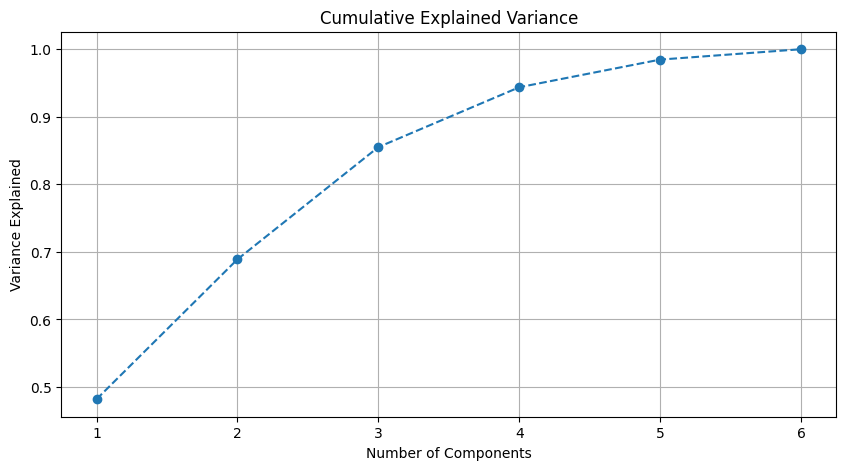

Top factors for PC1:
Rural_Urban_Continuum_Code    0.561686
Urban_Influence_Code          0.528219
Unemployment_rate             0.026295
Civilian_labor_force         -0.040650
Median_Household_Income      -0.331686
Metro                        -0.541418
Name: PC1, dtype: float64


In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_cols)

pca = decomposition.PCA()
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    data=pca_data, 
    columns=[f'PC{i+1}' for i in range(len(num_cols.columns))]
)

print(f"Explained Variance Ratio:\n{pca.explained_variance_ratio_}\n")
print(f"Total variance captured by first component: {pca.explained_variance_ratio_[0]:.2%}\n")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(num_cols.columns))],
    index=num_cols.columns
)

# Show what drives PC1 (usually the most important economic factor)
print("Top factors for PC1:")
print(loadings['PC1'].sort_values(ascending=False))

The first principal component explains slightly less than half of the data's variance which is not enough to capture an accurate depiction of the data. Looking at the graph above, I'd be more comfortable to use the principal components up to 4 or 5 which explains over 90% of the data.

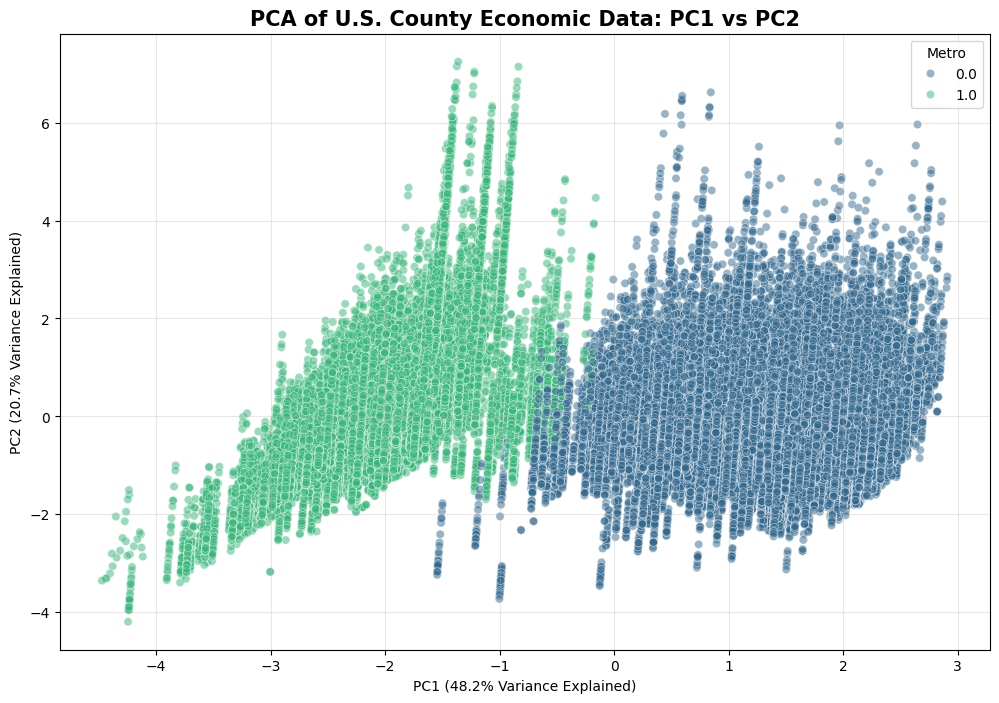

In [46]:
pca_features = pca.transform(scaled_data)

plot_df = pd.DataFrame(
    data=pca_features[:, :2], 
    columns=['PC1', 'PC2']
)

# Add Categorical Metro data to color PCA graph
plot_df['Metro'] = house_income['Metro'].reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df, 
    x='PC1', 
    y='PC2', 
    hue='Metro', 
    alpha=0.5,
    palette='viridis'
)

plt.title('PCA of U.S. County Economic Data: PC1 vs PC2', fontsize=15, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance Explained)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance Explained)')
plt.grid(alpha=0.3)
plt.show()

After colorcoding the first two PCs on a scatter plot, this shows that within the data there is a mostly clear separation in economic factors between Non-Metro Counties and Metro Counties.

Linear Regression using Feature Selection (Forwards and Backwards)

In [ ]:
from sklearn.model_selection   import train_test_split, cross_val_score,RepeatedKFold
from sklearn.linear_model      import LinearRegression,Ridge,Lasso
from sklearn.model_selection   import GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics           import mean_squared_error, r2_score

# Forward Feature Selection
def forward_feature_selection(X, y, model, 
                              scoring='neg_root_mean_squared_error', 
                              cv = 5, 
                              tol=None,               # None = no delta cutoff
                                                      # use 0.0 for "no further improvements"
                                                      # and 1e-4 for "point of diminishing returns"                                      
                              max_features=None,      # None = use all features
                              n_jobs=-1,
                              verbose=False
                             ):
    selected_features = []                            # List to store the order of features selected
    remaining_features = list(X.columns)              # Features not yet selected
    best_scores = []                                  # List to store the CV score after each feature addition
    previous_score = float('inf')                     # Initialize previous score for improvement comparison

    # Track the best subset of features and its corresponding score
    
    best_feature_set = None                           # Best combination of features found so far
    best_score = float('inf')                         # Best CV score observed so far
    
    while remaining_features:
        scores = {}                                   # Dictionary to hold CV scores for each candidate feature
        for feature in remaining_features:
            current_features = selected_features + [feature]
            
            # Compute the CV score for the current set of features (negated MSE, so lower is better)
            cv_score = -cross_val_score(model, X[current_features], y, 
                                        scoring=scoring, cv=cv, n_jobs=n_jobs
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]
            
        # Check if the improvement is significant based on the tolerance (tol)
        if tol is not None and previous_score - current_score < tol:
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list and update score trackers
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"\nFeatures: {selected_features[-3:]}, CV Score (MSE): {current_score:.4f}")
        
        # Update the best subset if the current score is better than the best so far
        if current_score < best_score:
            best_score = current_score
            best_feature_set = selected_features.copy()
        
        # Check if the maximum number of features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return (
        selected_features,      # List of features in the order they were selected (this will be ALL features if max_features == None
        best_scores,            # List of cross-validation scores corresponding to each addition in the previous list
        best_feature_set,       # The subset of features that achieved the best CV score.
        best_score              # The best CV score
    )

# Backward Feature Selection
def backward_feature_selection(X, y, model, 
                               scoring='neg_root_mean_squared_error', 
                               cv = 5, 
                               tol=None,               # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"                                      
                               max_features=None,      # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs=-1,
                               verbose=True
                              ):
    
    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y, 
                                scoring=scoring, cv=cv, 
                                n_jobs=n_jobs          ).mean()
    
    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)
    
    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)
    
    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)
    
    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (MSE): {np.around(initial_score, 4)}\n')
    
    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features
    
    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')
            
        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None
        
        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set
        
        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break
        
        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()
        
        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)
        
        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (MSE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )

In [81]:
cancer_deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578489 entries, 0 to 1578488
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   AGE                    1578467 non-null  float64
 1   SEX                    1578489 non-null  object 
 2   SEX_CODED              1578489 non-null  object 
 3   RACE                   1578489 non-null  object 
 4   ETHNIC_GROUP           1578489 non-null  object 
 5   HISPANIC_CODED         1578489 non-null  int64  
 6   MARITAL_STATUS         1578489 non-null  object 
 7   MARITAL_STATUS_CODED   1578489 non-null  object 
 8   EDUCATION              1578489 non-null  object 
 9   EDUCATION_CODED        1578489 non-null  int64  
 10  RESIDENT_STATUS        1578489 non-null  object 
 11  RESIDENT_STATUS_CODED  1578489 non-null  int64  
 12  CAUSE_OF_DEATH         1578489 non-null  object 
 13  CAUSE_RECODE_113       1578489 non-null  int64  
 14  MANNER_OF_DEATH   

In [87]:
numeric_columns = cancer_deaths.select_dtypes("number").drop(columns=['MANNER_OF_DEATH']).dropna() # dropped MANNER_OF_DEATH since it is empty

X = numeric_columns.drop(columns=['AGE'])
y = numeric_columns['AGE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

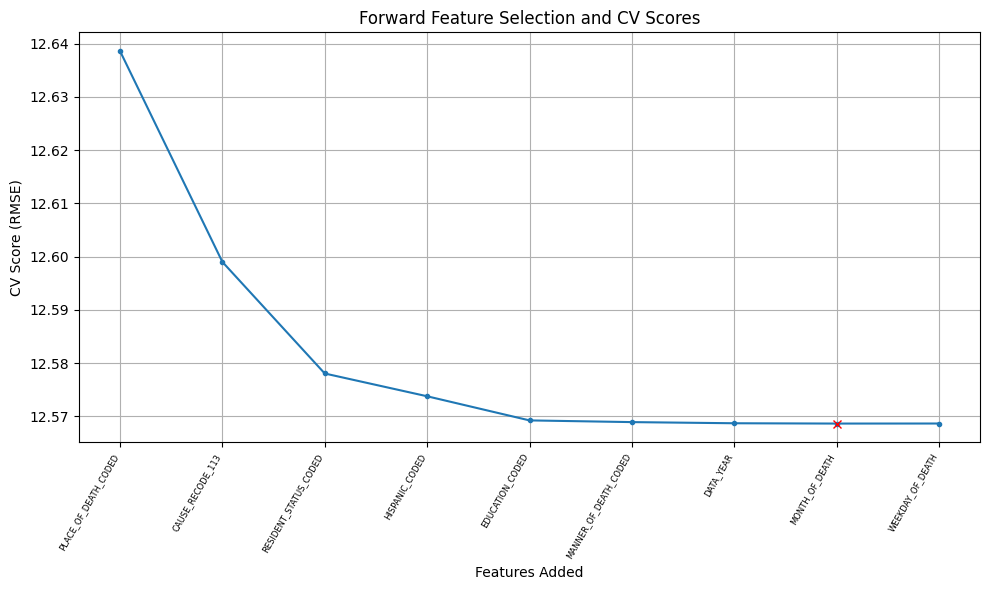

Best Features: ['PLACE_OF_DEATH_CODED', 'CAUSE_RECODE_113', 'RESIDENT_STATUS_CODED', 'HISPANIC_CODED', 'EDUCATION_CODED', 'MANNER_OF_DEATH_CODED', 'DATA_YEAR', 'MONTH_OF_DEATH']
Best CV Score: 12.5686


In [89]:
model = LinearRegression()

selected_features, best_scores, best_forward_features, best_score =    (
            forward_feature_selection(X_train, y_train, model, verbose=False) )

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
plt.plot([index+1],best_score,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=60, ha='right', fontsize=6) 
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_score:.4f}")

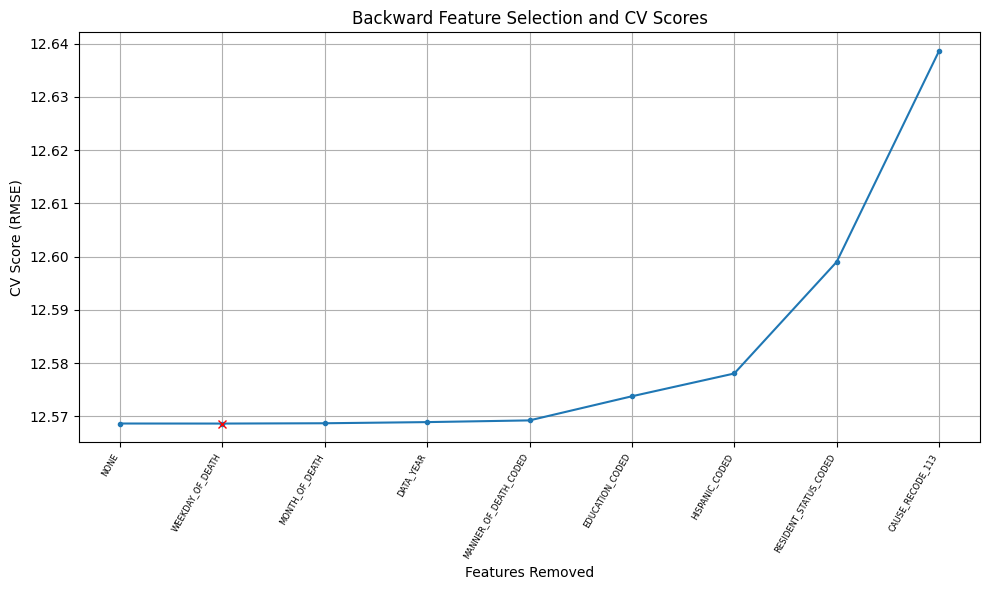

Best feature set: ['HISPANIC_CODED', 'EDUCATION_CODED', 'RESIDENT_STATUS_CODED', 'CAUSE_RECODE_113', 'MANNER_OF_DEATH_CODED', 'PLACE_OF_DEATH_CODED', 'DATA_YEAR', 'MONTH_OF_DEATH']
CV score (MSE): 12.5686


In [90]:
model = LinearRegression()

selected_features, best_scores, best_feature_set, best_score = (
    backward_feature_selection(X_train, y_train, model, verbose=False)                             
)

plt.figure(figsize=(10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
index = np.argmin(best_scores) 
plt.plot([index + 1], best_scores[index], marker='x', color='red')  
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=60, ha='right', fontsize=6)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print minimum cv score

print("Best feature set:", best_feature_set)
print("CV score (MSE):",np.around(best_score,4))

I ran forwards and backwards feature selection using a linear regression model in order to predict `AGE` in my cancer deaths dataset. Both feature selection algorithms used the same features just printed in a different order. However, I noticed that running linear regression is not going to be best for this particular problem because of the high RMSE of the best sets being 12.57 years which is not exactly a small error for age. I will need to use more complex models like a random forest or something else that will capture non-linear relationships better.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

<Figure size 1000x1000 with 0 Axes>

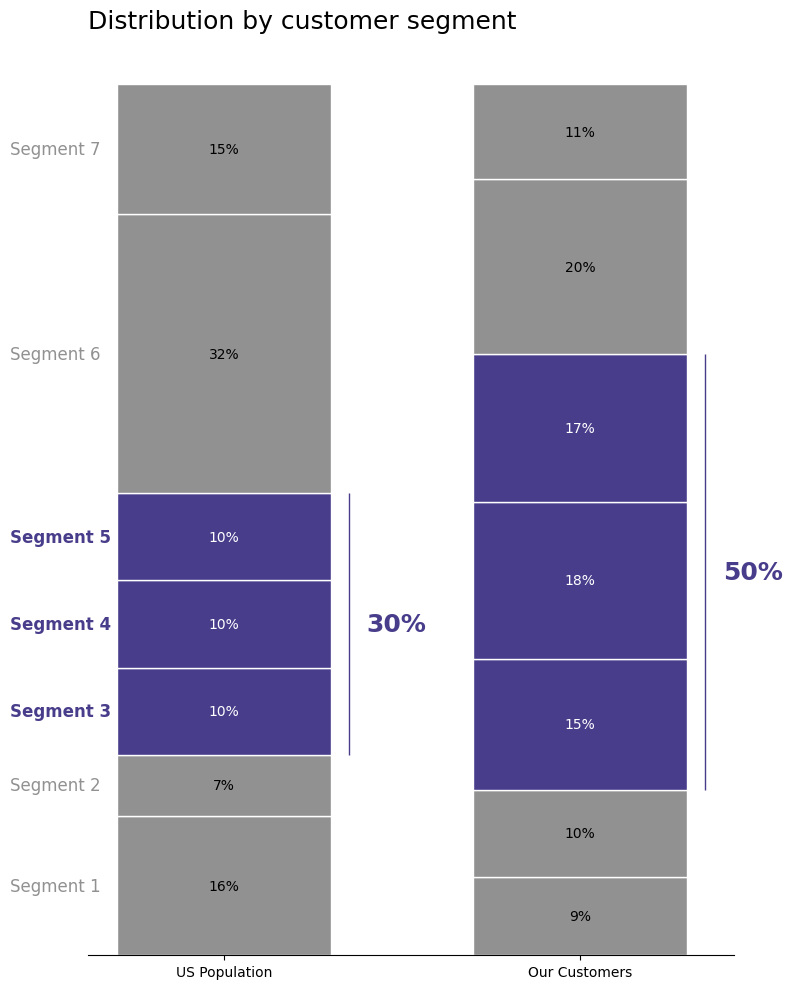

In [104]:
plt.figure(figsize=(10,10))

us_pop_vals = [16,7,10,10,10,32,15]
customer_vals = [9,10,15,18,17,20,11]

labels = ['US Population', 'Our Customers']
data = np.array([us_pop_vals, customer_vals]).T

colors = [
    "#919191", '#919191',               # Segments 1, 2
    '#483D8B', '#483D8B', '#483D8B',  # Segments 3, 4, 5
    "#919191", '#919191',               # Segments 6, 7
]

fig, ax = plt.subplots(figsize=(8,10))

# stack bars on 0
bottoms = np.zeros(len(labels))

for i in range(len(data)):
    total_per_bar = data.sum(axis=0)
    percentages = data[i]

    if i == 2: # Segment 3
        purple_starts = bottoms.copy()

    bars = ax.bar(labels, percentages, bottom=bottoms, color=colors[i], edgecolor='white', width=0.6)

    if i == 4: # End of Segment 5
        purple_ends = bottoms + percentages

    is_purple = i in [2, 3, 4]
    ax.text(
        -0.6,
        bottoms[0] + percentages[0] / 2,
        f"Segment {i+1}",
        va='center',
        ha='left',
        fontsize=12,
        color=colors[i],
        fontweight='bold' if is_purple else 'normal'
    )

    for j, bar in enumerate(bars):
        height = bar.get_height()

        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{percentages[j]}%',
                ha='center', va='center',
                color='white' if i in [2, 3, 4] else 'black'
            )
    
    # update bottom for next stack        
    bottoms += percentages

# Adding vertical lines and summed totals of purple segments
purple_sums = [sum(us_pop_vals[2:5]), sum(customer_vals[2:5])]

for s, label in enumerate(labels):
    line_x = s + 0.35

    ax.vlines(x=line_x, 
              ymin=purple_starts[s], 
              ymax=purple_ends[s], 
              color='#483D8B', 
              linewidth=1)

    ax.text(line_x + 0.05,
            (purple_starts[s] + purple_ends[s]) / 2,
            f"{purple_sums[s]}%",
            color='#483D8B',
            fontsize=18,
            fontweight='bold',
            va='center',
            ha='left'
        )

ax.set_ylim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)

ax.set_title("Distribution by customer segment",
             loc='left',
             pad=40,
             fontsize=18
            )

plt.tight_layout()
plt.show()